In [1]:
# 1. Instalar MuJoCo y mediapy
!pip install mujoco
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy

# 2. Actualizar el gestor de paquetes E INSTALAR OSMesa
# Añadimos 'apt-get update' para evitar los errores 404 Not Found
!apt-get update && apt-get install -y -qq libosmesa6-dev libgl1-mesa-glx > /dev/null

# 3. Forzar a MuJoCo a usar el backend 'osmesa' (CPU) en lugar de 'egl' (GPU)
import os
os.environ['MUJOCO_GL'] = 'osmesa'

import mujoco as mj
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt

print("¡Entorno de MuJoCo configurado con éxito para CPU usando OSMesa!")

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
¡Entorno de MuJoCo configurado con éxito para CPU usando OSMesa!


In [2]:
# 1. Tu modelo XML
xml_string = """
<mujoco model="manipulador_1r">
    <compiler coordinate="local" angle="degree"/>
    <option gravity="0 0 -9.81" timestep="0.002"/>
    <worldbody>
        <light dir="0 0 -1" diffuse="0.5 0.5 0.5" pos="0 0 3"/>
        <geom type="plane" size="2 2 0.1" rgba="0.9 0.9 0.9 1"/>
        <body name="base" pos="0 0 1.5">
            <geom type="sphere" size="0.05" rgba="0.2 0.2 0.2 1"/>
            <body name="link1" pos="0 0 0">
                <joint name="articulacion_R" type="hinge" axis="0 0 1" pos="0 0 0" damping="0.1"/>
                <geom type="cylinder" size="0.03" fromto="0 0 0  0.5 0 0" rgba="0.8 0.2 0.2 1"/>
                <geom type="sphere" size="0.05" pos="0.5 0 0" rgba="0.1 0.8 0.1 1"/>
            </body>
        </body>
    </worldbody>
    <actuator>
        <motor name="motor_R" joint="articulacion_R" gear="1" ctrllimited="true" ctrlrange="-50 50"/>
    </actuator>
</mujoco>
"""

model = mj.MjModel.from_xml_string(xml_string)
data = mj.MjData(model)

# --- CONFIGURACIÓN DE RENDERIZADO ---
renderer = mj.Renderer(model, height=480, width=640)
renderer.scene.flags[mj.mjtRndFlag.mjRND_SHADOW] = 0
renderer.scene.flags[mj.mjtRndFlag.mjRND_REFLECTION] = 0

# Posición inicial: 45 grados hacia arriba
data.qpos[0] = np.radians(45.0)

# Parámetros de Control y Simulación
posicion_deseada = np.radians(0.0)
kp = 50.0
kd = 5.0
duracion = 3.0
pasos = int(duracion / model.opt.timestep)

fps = 30
pasos_por_frame = int(1 / (fps * model.opt.timestep))
frames = []

historial_tiempo = []
historial_torque = []
historial_posicion = []

# Cámara estática
camera = mj.MjvCamera()
camera.type = mj.mjtCamera.mjCAMERA_FREE
mj.mjv_defaultCamera(camera)
camera.distance = 2.0
camera.lookat = [0.25, 0, 1.5]
camera.elevation = -15

# 4. Bucle principal de física + control
for paso in range(pasos):

    # [CORRECCIÓN] Forzar cálculo de fuerzas y dinámica antes de aplicar el control
    mj.mj_forward(model, data)

    # --- ZONA DE CONTROL ---
    q = data.qpos[0]
    dq = data.qvel[0]

    error = posicion_deseada - q
    error_derivativo = 0.0 - dq

    torque_pd = (kp * error) + (kd * error_derivativo)

    # [CORRECCIÓN] data.qfrc_bias incluye Coriolis, fuerzas centrífugas y gravedad.
    # Se suma porque contrarresta directamente los efectos dinámicos del robot.
    torque_gravedad = data.qfrc_bias[0]

    data.ctrl[0] = torque_pd + torque_gravedad
    # -----------------------

    # Resolver la física (avanza el tiempo)
    mj.mj_step(model, data)

    # Guardar datos para las gráficas
    historial_tiempo.append(paso * model.opt.timestep)
    historial_torque.append(data.actuator_force[0])
    historial_posicion.append(np.degrees(q))

    # --- RENDERIZADO ---
    if paso % pasos_por_frame == 0:
        # Actualizar la escena usando el estado actual de data
        renderer.update_scene(data, camera=camera)

        # Renderizar
        rgb_img = renderer.render()

        # Guardar frame
        frames.append(np.array(rgb_img, dtype=np.uint8))

# 5. Mostrar la animación
print("Mostrando video corregido...")
media.show_video(frames, fps=fps)

Mostrando video corregido...


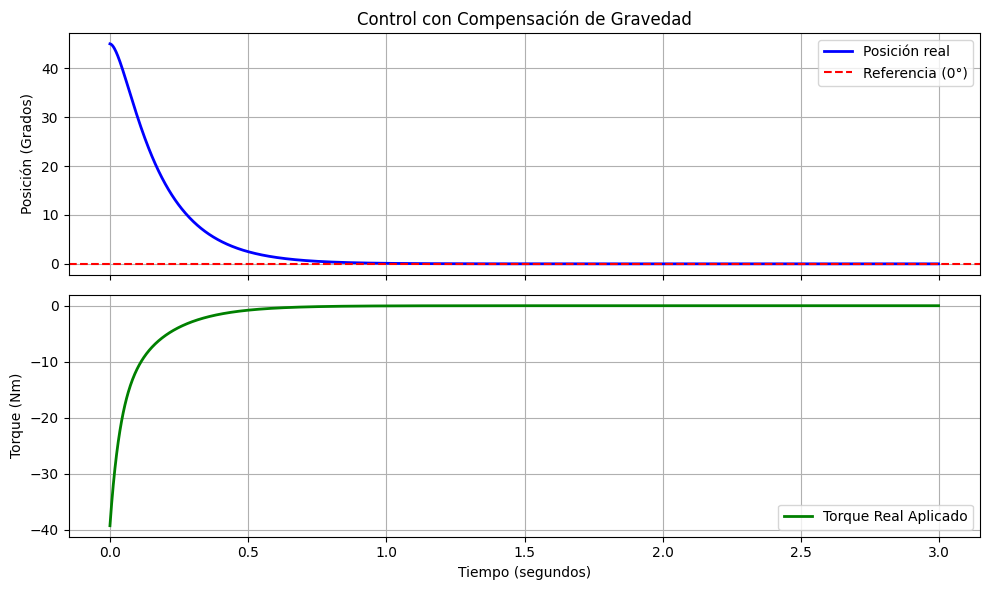

In [5]:
# 6. Graficar resultados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(historial_tiempo, historial_posicion, color='blue', lw=2, label='Posición real')
ax1.axhline(y=np.degrees(posicion_deseada), color='red', linestyle='--', label='Referencia (0°)')
ax1.set_ylabel('Posición (Grados)')
ax1.set_title('Control con Compensación de Gravedad')
ax1.grid(True)
ax1.legend()

ax2.plot(historial_tiempo, historial_torque, color='green', lw=2, label='Torque Real Aplicado')
ax2.set_xlabel('Tiempo (segundos)')
ax2.set_ylabel('Torque (Nm)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [6]:
historial_torque[-1]

np.float64(-1.208004539637631e-07)